In [1]:
import matplotlib.pyplot as plt
import numpy as np
from cond_dist import ConditionalDistribution
from knapsack import solve_fractional_knapsack_problem
from tqdm import tqdm
from conditional_program import solve_conditional_program

In [2]:
np.random.seed(0)
xs= [0., 1.]
scales = [1., 1.5]
shapes = [1., 1.]
# xs = np.random.uniform(0., 3., 10)
# scales = np.random.uniform(1., 1.5, 10)
# shapes = np.ones(10)
p_xs = np.ones(len(xs))/len(xs)
budget=0.05
c_bar = 8.
cond_dists = [ConditionalDistribution(xs[i], scales[i], shapes[i]) for i in range(len(xs))]

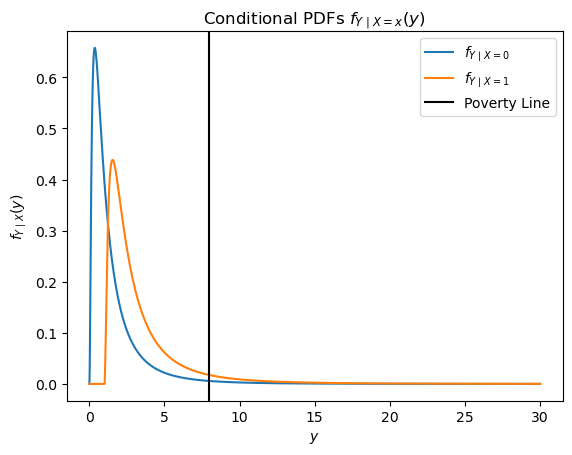

In [3]:
zs = np.linspace(0., 30, 2000)
plt.plot(zs, cond_dists[0].pdf(zs), label=r"$f_{Y \mid X=0}$")
plt.plot(zs, cond_dists[1].pdf(zs), label=r"$f_{Y \mid X=1}$")
plt.axvline(x=c_bar, label="Poverty Line", color='black')
plt.xlabel(r"$y$")
plt.ylabel(r"$f_{Y \mid X}(y)$")
plt.legend()
plt.title("Conditional PDFs " + r"$f_{Y \mid X=x}(y)$")
plt.savefig("paper_figs/toy_pdfs.pdf", bbox_inches="tight")

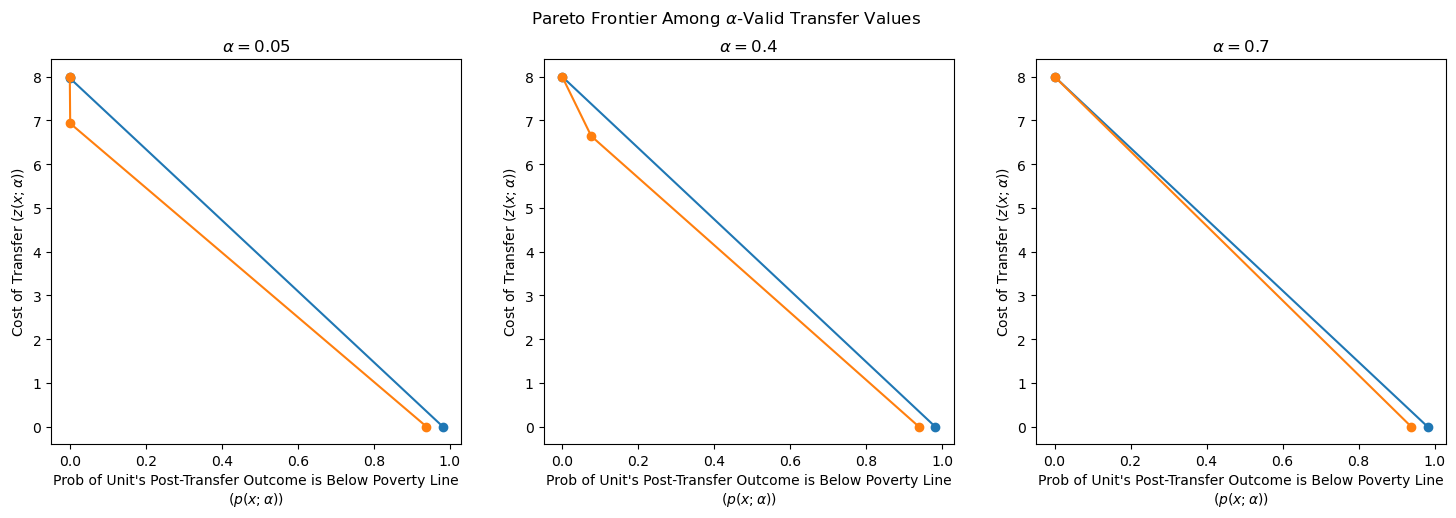

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

for i, alpha in enumerate([0.05, 0.4, 0.7]):
    for j, c_dist in enumerate(cond_dists):
        lower_cvx_hull = c_dist.get_convex_hull(alpha, c_bar)
        ax[i].plot(lower_cvx_hull[:, 0], lower_cvx_hull[:, 1], marker="o", label=r"$x={}$".format(xs[j]))
    ax[i].set_xlabel("Prob of Unit's Post-Transfer Outcome is Below Poverty Line\n" + r"$(p(x; \alpha))$" )
    ax[i].set_ylabel("Cost of Transfer " + r"$(z(x; \alpha))$")
    ax[i].set_title(r"$\alpha = {}$".format(alpha))
plt.suptitle("Pareto Frontier Among " + r"$\alpha$" + "-Valid Transfer Values")
plt.savefig("paper_figs/pareto.pdf", bbox_inches="tight")

In [5]:
total_transfers = []
opt_policies = []
alphas =  np.linspace(1e-3, 0.7, 20000)
for alpha in tqdm(alphas):
    cvx_hulls = [c_dist.get_convex_hull(alpha, c_bar) for c_dist in cond_dists]
    opt_policy, total_transfer = solve_fractional_knapsack_problem(xs, p_xs, cvx_hulls, budget)
    total_transfers.append(total_transfer)
    opt_policies.append(opt_policy)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20000/20000 [00:17<00:00, 1120.90it/s]


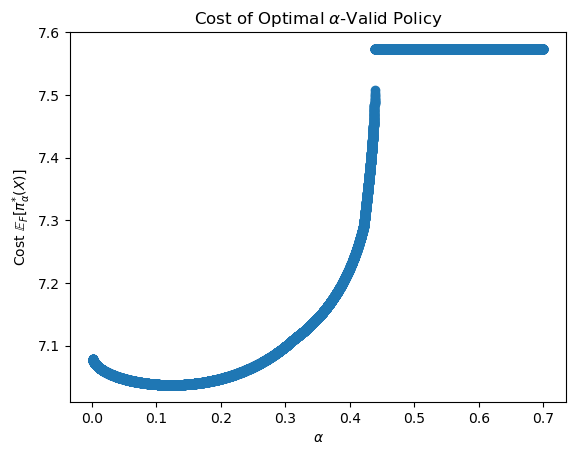

In [6]:
plt.scatter(alphas, total_transfers)
plt.xlabel(r"$\alpha$")
plt.ylabel("Cost " + r"$\mathbb{E}_{F}[\pi_{\alpha}^{*}(X)]$")
plt.title("Cost of Optimal " + r"$\alpha$"+"-Valid Policy")
plt.savefig("paper_figs/cost.png", bbox_inches="tight")

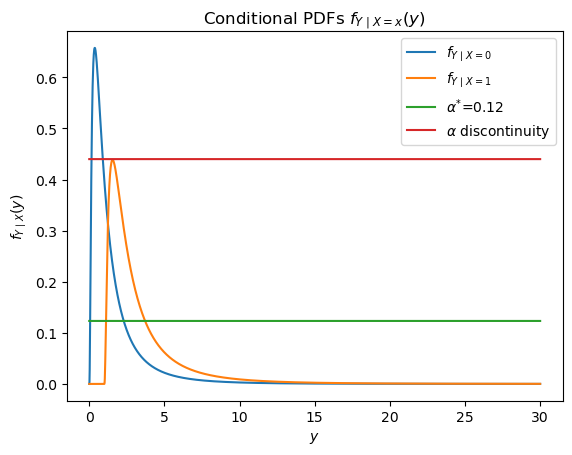

In [7]:
best_idx = np.argmin(total_transfers)
best_alpha = alphas[best_idx]
zs = np.linspace(0., 30, 2000)
plt.plot(zs, cond_dists[0].pdf(zs), label=r"$f_{Y \mid X=0}$")
plt.plot(zs, cond_dists[1].pdf(zs), label=r"$f_{Y \mid X=1}$")
plt.plot(zs, np.ones(2000) * best_alpha, label=r"$\alpha^{*}$" +"={}".format(round(best_alpha, 2)) )
plt.plot(zs, np.ones(2000) * 0.44, label=r"$\alpha$" + " discontinuity")
plt.xlabel(r"$y$")
plt.ylabel(r"$f_{Y \mid X}(y)$")
plt.legend()
plt.title("Conditional PDFs " + r"$f_{Y \mid X=x}(y)$")
plt.savefig("paper_figs/pdfs_with_opt_alpha.pdf", bbox_inches="tight")

In [8]:
total_transfers[best_idx], opt_policies[best_idx], best_alpha

(7.037518758436745,
 {0: [(7.940989112633543, 0.9050780455260121), (0.0, 0.09492195447398788)],
  1: [(6.887822611267781, 1)]},
 0.12326121306065303)

In [9]:
solve_conditional_program(p_xs, cond_dists, budget, c_bar)

({0: [7.806959183301263], 1: [6.7104387749518954]}, 7.25869897912658)